# 2026 국가데이터 활용대회
## 고령층 경제 이질성 진단 — VDR 분석 파이프라인

**실행 순서**: 셀을 위에서 아래로 순서대로 실행하세요 (`Shift + Enter`)

| 셀 | 내용 |
|---|---|
| 1 | 패키지 설치 확인 |
| 2 | 경로 설정 ← **여기만 수정** |
| 3 | 공통 함수 및 상수 정의 |
| 4 | STEP 1: 가계금융복지조사 |
| 5 | STEP 2: SGIS 등록부 |
| 6 | STEP 4~9: 민간 데이터 |
| 7 | STEP 10: 시각화 |
| 8 | 전체 실행 |

> **VDR 반출 규정 4가지 준수**  
> 규정 1: 로우 데이터 반출 금지 → groupby 집계만 저장  
> 규정 2: K-Anonymity → 건수 < 5 행 자동 삭제  
> 규정 3: 파일 포맷 → .xlsx / .png 저장만 허용  
> 규정 4: inf/NaN 방어 → 모든 연산 전 클렌징  

In [1]:
# [셀 1] 패키지 설치 확인
# 주피터 노트북에서는 ! 로 터미널 명령 실행 가능
import sys

required = ['pandas', 'numpy', 'matplotlib', 'openpyxl', 'sklearn']
missing  = []

for pkg in required:
    try:
        __import__(pkg)
        print(f'  ✓ {pkg}')
    except ImportError:
        missing.append(pkg)
        print(f'  ✗ {pkg} — 미설치')

if missing:
    print(f'\n아래 셀을 실행해서 설치하세요:')
    print(f'  !pip install {" ".join(missing)}')
else:
    print('\n✓ 모든 패키지 준비 완료')

  ✓ pandas
  ✓ numpy
  ✓ matplotlib
  ✓ openpyxl
  ✓ sklearn

✓ 모든 패키지 준비 완료


In [2]:
# [셀 1-b] 패키지 미설치 시에만 실행 (인터넷 연결 필요)
# 인터넷 차단 환경이면 오프라인 설치 방법 사용
!pip install pandas numpy matplotlib openpyxl scikit-learn

# 오프라인 설치 (packages 폴더에 whl 파일이 있는 경우)
# !pip install --no-index --find-links=./packages pandas numpy matplotlib openpyxl scikit-learn
print('필요 시 위 주석을 해제하고 실행하세요')

필요 시 위 주석을 해제하고 실행하세요



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ================================================================
# [셀 2] ★★★ 경로 설정 — 이 셀만 수정하면 됩니다 ★★★
# ================================================================
from pathlib import Path

# ── 출력 저장 위치 (결과 엑셀·이미지가 저장될 폴더) ──────────
# 현재 노트북 파일과 같은 폴더에 output 폴더를 만들어 저장
BASE_DIR = Path('.')          # 노트북 파일 위치 기준
OUT_XLS  = BASE_DIR / 'output' / 'excel'
OUT_IMG  = BASE_DIR / 'output' / 'images'
OUT_XLS.mkdir(parents=True, exist_ok=True)
OUT_IMG.mkdir(parents=True, exist_ok=True)

# ── 가계금융복지조사 경로 ─────────────────────────────────────
# 예시) Windows: Path('C:/VDR데이터/가계금융복지조사/2023_가구마스터.csv')
# 예시) Linux:   Path('/Rdata1/r1_user138/dataset/가구마스터/2023.csv')
#HFWS_2023 = Path('/Rdata1/r1_user138/dataset/가계금융복지조사/2023_가구마스터_20260512_38026.csv')
#HFWS_2024 = Path('/Rdata1/r1_user138/dataset/가계금융복지조사/2024_가구마스터_20260512_38026.csv')
HFWS_2023 = Path('C:/Users/yooyj/OneDrive/문서/Code/Data/sample_data/가계금융복지조사/2023_가구마스터_20260512_38026.csv')
HFWS_2024 = Path('C:/Users/yooyj/OneDrive/문서/Code/Data/sample_data/가계금융복지조사/2024_가구마스터_20260512_38026.csv')
# ── SGIS 등록부 경로 ─────────────────────────────────────────
RDATA     = Path('C:/Users/yooyj/OneDrive/문서/Code/Data/sample_data')
POP_2023  = RDATA / 'A09_POPULATION/POPULATION_2023.txt'
HHD_2023  = RDATA / 'A10_HOUSEHOLD/HOUSEHOLD_2023.txt'
HSG_2023  = RDATA / 'A11_HOUSING/HOUSING_2023.txt'

# ── 민간 데이터 경로 ─────────────────────────────────────────
CARD_SEOUL_DIR = RDATA / 'P46_CARD_SALES/03.CARD_DOMESTIC_SEL'
CARD_APT_DIR   = RDATA / 'P46_CARD_SALES/07.CARD_APARTMENT'
NICE_LOAN_DIR  = RDATA / 'P47_NICE_CREDIT/01.LOAN_ADM'
NICE_INCOM_DIR = RDATA / 'P47_NICE_CREDIT/02.INCOM_ADM'
NICE_POS_DIR   = RDATA / 'P47_NICE_CREDIT/07.POS_SGG'
NH_APT_DIR     = RDATA / 'P49_NHCARD/05.NH_APARTMENT'

# ── 경로 존재 확인 ────────────────────────────────────────────
print('경로 확인 결과:')
for name, path in [
    ('가구마스터 2023', HFWS_2023),
    ('가구마스터 2024', HFWS_2024),
    ('SGIS 인구',       POP_2023),
    ('SGIS 가구',       HHD_2023),
    ('SGIS 주택',       HSG_2023),
    ('카드소비(서울)', CARD_SEOUL_DIR),
    ('NICE 대출',       NICE_LOAN_DIR),
    ('NICE 소득',       NICE_INCOM_DIR),
]:
    ok = '✓' if path.exists() else '✗ 경로 없음 — 위 경로를 확인하세요'
    print(f'  {ok}  {name}: {path}')

print(f'\n출력 폴더: {OUT_XLS.resolve()}')

경로 확인 결과:
  ✓  가구마스터 2023: C:\Users\yooyj\OneDrive\문서\Code\Data\sample_data\가계금융복지조사\2023_가구마스터_20260512_38026.csv
  ✓  가구마스터 2024: C:\Users\yooyj\OneDrive\문서\Code\Data\sample_data\가계금융복지조사\2024_가구마스터_20260512_38026.csv
  ✓  SGIS 인구: C:\Users\yooyj\OneDrive\문서\Code\Data\sample_data\A09_POPULATION\POPULATION_2023.txt
  ✓  SGIS 가구: C:\Users\yooyj\OneDrive\문서\Code\Data\sample_data\A10_HOUSEHOLD\HOUSEHOLD_2023.txt
  ✓  SGIS 주택: C:\Users\yooyj\OneDrive\문서\Code\Data\sample_data\A11_HOUSING\HOUSING_2023.txt
  ✓  카드소비(서울): C:\Users\yooyj\OneDrive\문서\Code\Data\sample_data\P46_CARD_SALES\03.CARD_DOMESTIC_SEL
  ✓  NICE 대출: C:\Users\yooyj\OneDrive\문서\Code\Data\sample_data\P47_NICE_CREDIT\01.LOAN_ADM
  ✓  NICE 소득: C:\Users\yooyj\OneDrive\문서\Code\Data\sample_data\P47_NICE_CREDIT\02.INCOM_ADM

출력 폴더: C:\Users\yooyj\OneDrive\문서\Code\Data\output\excel


In [ ]:
# [셀 3] 공통 라이브러리·상수·함수 정의 (수정 불필요)
import pandas as pd
import numpy as np
import matplotlib
# 주피터 노트북: inline으로 변경 (Agg 대신 화면에 바로 표시)
import matplotlib.pyplot as plt
import gc
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux (VDR 환경)
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        pass
plt.rcParams['axes.unicode_minus'] = False

# 기본 설정값
SEP   = '|'
CHUNK = 200_000   # 메모리 부족 시 50_000으로 줄이세요

# 수도권 시도코드 (서울 11 + 인천 28 + 경기 41)
METRO_SIDO = ['11', '28', '41']

# 연도별 동적 빈곤선
MEDIAN_INCOME_BY_YEAR = {
    2023: {1:2_077_892, 2:3_456_155, 3:4_434_816,
           4:5_400_964, 5:6_330_688, 6:7_227_981, 7:8_107_515},
    2024: {1:2_228_445, 2:3_682_609, 3:4_714_657,
           4:5_729_913, 5:6_695_735, 6:7_618_369, 7:8_514_994},
}
MEDIAN_INCOME_ADD = {2023: 879_534, 2024: 896_625}

INC_COL = '처분가능소득(보완)[경상소득(보완)-비소비지출(보완)]'
RE_COL  = '자산_실물자산_부동산_거주주택금액'
WT_COL  = '가중값'

HFWS_COLS = [
    '조사연도', 'MD제공용_가구고유번호', WT_COL, '수도권여부', '가구원수',
    '노인가구여부', '가구주_만연령', '입주형태코드', '주택종류통합코드',
    '자산', '자산_금융자산', '자산_실물자산',
    RE_COL, '부채', '부채_금융부채_담보대출금액', '순자산',
    '경상소득(보완)', '경상소득_공적이전소득(보완)', INC_COL,
    '지출_소비지출비', '지출_소비지출_식료품(외식비포함)',
    '지출_소비지출_의료비', '지출_비소비지출(보완)',
    '지출_비소비지출_세금(보완)',
    '지출_비소비지출_공적연금사회보험료(보완)',
    '지출_비소비지출_연간지급이자(조사2)',
    '가구주_은퇴여부', '가구주_미은퇴_최소생활비',
    '가구주_미은퇴_적정생활비', '가구주_은퇴_적정생활비충당여부',
]
NA_VALS = ['*','**','***','****','*****','******','*******',
           '********','*********','**********','.']

# ── 공통 함수 3종 (VDR 반출 규정 핵심) ──────────────────────
def clean_inf_nan(df, fill_val=0):
    """규정 4: inf/-inf → NaN → fill_val"""
    num = df.select_dtypes(include=[np.number]).columns
    df[num] = df[num].replace([np.inf, -np.inf], np.nan).fillna(fill_val)
    return df

def apply_k_anonymity(df, count_col, k=5):
    """규정 2: 건수 < k 행 제거"""
    before = len(df)
    df = df[df[count_col] >= k].copy()
    print(f'  [K-익명화] {before - len(df)}행 제거 → 잔여 {len(df)}행')
    return df

def save_xlsx(df, filename):
    """규정 3: .xlsx로만 저장"""
    path = OUT_XLS / filename
    df.to_excel(path, index=False, engine='openpyxl')
    print(f'  [저장] {filename}  ({len(df)}행)')

def get_dynamic_poverty_line(year, num_members):
    """연도·가구원수별 정부 고시 빈곤선(중위소득 50%, 연간 만원)"""
    year = int(year)
    num  = int(num_members) if not pd.isna(num_members) else 1
    if year not in MEDIAN_INCOME_BY_YEAR:
        year = max(MEDIAN_INCOME_BY_YEAR.keys())
    tbl = MEDIAN_INCOME_BY_YEAR[year]
    add = MEDIAN_INCOME_ADD[year]
    monthly = tbl[num] if num <= 7 else tbl[7] + (num - 7) * add
    return round((monthly * 0.5 * 12) / 10_000, 1)

def _open_txt(path, sep, dtype, chunk_size):
    """인코딩 자동 감지: UTF-8 실패 시 CP949 재시도"""
    for enc in ('utf-8', 'cp949'):
        try:
            return pd.read_csv(path, sep=sep, dtype=dtype, chunksize=chunk_size,
                               encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f'인코딩 감지 실패: {path}')

def iter_monthly_files(directory, prefix, suffix='.txt', months=range(1,13)):
    """월별 파일(01~12) 순서대로 yield"""
    for m in months:
        fname = f"{prefix}{m:02d}{suffix}"   # 수정: replace 방식 제거
        p = directory / fname
        if p.exists():
            yield m, p
        else:
            print(f'  [없음] {fname}')

def get_card_cols(chunk):
    c = chunk.iloc[:, [3,10,12,14,16,21,25,26,27,28]].copy()
    c.columns = [
        '가맹점시군구코드', '업종코드', '조직구분',
        '연령코드', '고객시도코드', '고객시군구코드',
        '가구형태코드', '카드사용건수', '카드사용금액',
        '1인당평균사용금액',
    ]
    return c
def get_nice_loan_cols(chunk):
    """NICE 대출·연체 — 인덱스로 필요 컬럼만 추출 후 단순 한글명 부여"""
    c = chunk.iloc[:, [1,2,3,10,11,12,17,20,21,27,28,43,44,47,49]].copy()
    c.columns = [
        '구분명', '광역시도코드', '시군구코드', '성별', '연령구간대', '직업구분',
        '대출보유대상자수', '대출잔액_평균금액', '대출잔액_주택담보_평균금액',
        '총대출잔액', '총대출잔액_주택담보', '대출평균이자율',
        '월_연체보유자수_합계', '평균연체금액', '연체금액',
    ]
    return c

def get_nice_incom_cols(chunk):
    """NICE 소득 — 인덱스로 필요 컬럼만 추출 후 단순 한글명 부여"""
    c = chunk.iloc[:, [1,2,3,10,11,12,16,17,18,19]].copy()
    c.columns = [
        '구분명', '광역시도코드', '시군구코드', '성별', '연령구간대', '직업구분',
        '거주자수', '평균_연소득_금액', '중위_연소득_금액', '총연소득합계',
    ]
    return c

def get_card_apt_cols(chunk):
    """아파트단지소비(통합·농협) — 인덱스로 필요 컬럼만 추출 후 단순 한글명 부여"""
    c = chunk.iloc[:, [1,2,9,11,12,13,15,17,18,20,21,23,25,27]].copy()
    c.columns = [
        '고객시도코드', '고객시군구코드', '단지코드', '연평균소득금액', '성별코드', '연령코드',
        '건강관심비율', '골프관심비율', '독서관심비율', '뷰티관심비율',
        '쇼핑관심비율', '여행관심비율', '온라인쇼핑관심비율', '식도락관심비율',
    ]
    return c

def get_pos_sgg_cols(chunk):
    """외식업물가 — 인덱스로 필요 컬럼만 추출 후 단순 한글명 부여"""
    c = chunk.iloc[:, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]].copy()
    c.columns = [
        '광역시도코드', '시군구코드', '시군구명',
        '업종코드', '업종명',
        '평균단가', '거래건수', '평균매출금액',
        '전월대비변화율', '전년동월대비변화율',
    ]
    return c

print('✓ 공통 함수 정의 완료')

✓ 공통 함수 정의 완료


In [5]:
# [셀 4] STEP 1 — 가계금융복지조사 로드 및 집계
print('[STEP 1] 가계금융복지조사 로드 (수도권 G1 필터)')

dfs = []
for path, yr in [(HFWS_2023, 2023), (HFWS_2024, 2024)]:
    df = pd.read_csv(path, encoding='cp949', na_values=NA_VALS, low_memory=False)
    # 컬럼 수 확인 후 이름 부여
    if len(df.columns) == 30:
        df.columns = HFWS_COLS
    df['조사연도'] = yr
    dfs.append(df)
    print(f'  {yr}년: {len(df):,}행 로드')

panel = pd.concat(dfs, ignore_index=True)
panel = clean_inf_nan(panel)

# 수도권(G1) 필터 — 수도권여부 컬럼이 이미 서울+인천+경기 정의
panel = panel[panel['수도권여부'] == 'G1'].copy()

# 65세 이상 필터 및 연령 그룹
panel = panel[panel['가구주_만연령'] >= 65].copy()
panel['연령그룹'] = np.where(panel['가구주_만연령'] < 75,
                             '전기고령자(65-74)', '후기고령자(75+)')

# 연도별 동적 빈곤선
panel['정부기준빈곤선'] = panel.apply(
    lambda r: get_dynamic_poverty_line(r['조사연도'], r['가구원수']), axis=1)

# 파생변수
eps = 1e-6
panel['부동산편중도'] = np.where(panel['자산'] > 0,
                                panel[RE_COL] / panel['자산'], np.nan)
panel['경직적_비용비중'] = (
    panel['지출_비소비지출_세금(보완)'].fillna(0) +
    panel['지출_비소비지출_공적연금사회보험료(보완)'].fillna(0)
) / (panel['경상소득(보완)'] + eps)
panel['유동성_정체지수_raw'] = panel[RE_COL] / (panel[INC_COL] + 1)
for col in ['부동산편중도', '경직적_비용비중', '유동성_정체지수_raw']:
    panel[col] = panel[col].replace([np.inf, -np.inf], np.nan).fillna(0)

# 분위
panel['자산분위_내부'] = pd.qcut(panel[RE_COL].rank(method='first'),
                                5, labels=[1,2,3,4,5]).astype(int)
panel['소득분위_내부'] = pd.qcut(panel[INC_COL].rank(method='first'),
                                5, labels=[1,2,3,4,5]).astype(int)

# 유형 분류
def _classify(r):
    poor    = r[INC_COL] <= r['정부기준빈곤선']
    low_inc = r['소득분위_내부'] <= 2
    hi_ast  = r['자산분위_내부'] >= 4
    if poor and low_inc and hi_ast: return 'B유형_자산소득불일치'
    elif poor and r['자산분위_내부'] <= 2: return 'A유형_구조적취약층'
    elif not low_inc and hi_ast:    return 'D유형_여유자산가층'
    return 'C유형_기타일반가구'

panel['고령층유형'] = panel.apply(_classify, axis=1)
print(f'  수도권 고령 가구: {len(panel):,}행')
print(panel['고령층유형'].value_counts())

[STEP 1] 가계금융복지조사 로드 (수도권 G1 필터)
  2023년: 18,094행 로드
  2024년: 18,314행 로드
  수도권 고령 가구: 3,646행
고령층유형
C유형_기타일반가구     1578
D유형_여유자산가층     1125
A유형_구조적취약층      683
B유형_자산소득불일치     260
Name: count, dtype: int64


In [6]:
# [셀 4-b] STEP 1-A — 집계 및 VDR 반출용 xlsx 저장

# 집계 1: 유형 × 연령그룹 × 조사연도
grp1 = panel.groupby(['조사연도','연령그룹','고령층유형']).agg(
    표본수            = (WT_COL, 'count'),
    추정가구수_가중치 = (WT_COL, 'sum'),
    처분가능소득_평균 = (INC_COL, 'mean'),
    거주주택금액_평균 = (RE_COL,  'mean'),
    순자산_평균       = ('순자산', 'mean'),
    부동산편중도_평균 = ('부동산편중도', 'mean'),
    의료비_평균       = ('지출_소비지출_의료비', 'mean'),
).reset_index()
grp1 = clean_inf_nan(grp1)
grp1 = apply_k_anonymity(grp1, '표본수')
save_xlsx(grp1, '01_유형별_집계.xlsx')

# 집계 2: 수도권여부 × 연령그룹 × 유형
grp2 = panel.groupby(['조사연도','수도권여부','연령그룹','고령층유형']).agg(
    표본수            = (WT_COL, 'count'),
    추정가구수        = (WT_COL, 'sum'),
    처분가능소득_평균 = (INC_COL, 'mean'),
    거주주택금액_평균 = (RE_COL,  'mean'),
).reset_index()
grp2 = clean_inf_nan(grp2)
grp2 = apply_k_anonymity(grp2, '표본수')
save_xlsx(grp2, '02_수도권별_유형집계.xlsx')

# 집계 3: 주택종류 × 연령그룹
grp3 = panel.groupby(['조사연도','주택종류통합코드','연령그룹']).agg(
    표본수            = (WT_COL, 'count'),
    추정가구수        = (WT_COL, 'sum'),
    순자산_평균       = ('순자산', 'mean'),
    거주주택금액_평균 = (RE_COL,  'mean'),
    B유형_비율        = ('고령층유형',
                         lambda x: (x == 'B유형_자산소득불일치').mean()),
).reset_index()
grp3 = clean_inf_nan(grp3)
grp3 = apply_k_anonymity(grp3, '표본수')
save_xlsx(grp3, '03_주택종류별_집계.xlsx')

# 집계 4: 다각도 그루핑 매트릭스 (mean + var)
df_multi = panel.copy()
df_multi['부채유무'] = np.where(df_multi['부채'] > 0, '부채있음', '부채없음')
grp4 = df_multi.groupby(
    ['조사연도','연령그룹','수도권여부','주택종류통합코드','고령층유형','부채유무']
).agg(
    표본수                = (WT_COL,  'count'),
    추정가구수            = (WT_COL,  'sum'),
    처분가능소득_평균     = (INC_COL, 'mean'),
    처분가능소득_분산     = (INC_COL, 'var'),
    거주주택금액_평균     = (RE_COL,  'mean'),
    거주주택금액_분산     = (RE_COL,  'var'),
    유동성정체지수_평균   = ('유동성_정체지수_raw', 'mean'),
    유동성정체지수_분산   = ('유동성_정체지수_raw', 'var'),
    경직적비용비중_평균   = ('경직적_비용비중', 'mean'),
).reset_index()
var_cols  = [c for c in grp4.columns if '분산' in c]
mean_cols = [c for c in grp4.columns if '평균' in c]
grp4[var_cols]  = grp4[var_cols].fillna(0).round(2)
grp4[mean_cols] = grp4[mean_cols].round(2)
grp4 = clean_inf_nan(grp4)
grp4 = apply_k_anonymity(grp4, '표본수')
save_xlsx(grp4, '04_다각도_그루핑_매트릭스.xlsx')
del df_multi
gc.collect()
print('\n✓ STEP 1 완료')

  [K-익명화] 0행 제거 → 잔여 16행
  [저장] 01_유형별_집계.xlsx  (16행)
  [K-익명화] 0행 제거 → 잔여 16행
  [저장] 02_수도권별_유형집계.xlsx  (16행)
  [K-익명화] 0행 제거 → 잔여 16행
  [저장] 03_주택종류별_집계.xlsx  (16행)
  [K-익명화] 23행 제거 → 잔여 95행
  [저장] 04_다각도_그루핑_매트릭스.xlsx  (95행)

✓ STEP 1 완료


In [7]:
# ================================================================
# [셀 4-c] week3_4 파생변수(D_Value·LTI·AAI) + 이상치 처리 + 팀원 B·C 산출물
# ================================================================

# ── D-Value (실질소비여력 지수) ─────────────────────────────────
# 연간_카드지출 없으므로 가계조사 지출 항목으로 대리
eps = 1e-6
소비프록시 = (
    panel['지출_소비지출_식료품(외식비포함)'].fillna(0) +
    panel['지출_소비지출_의료비'].fillna(0)
)
panel['D_Value'] = np.where(
    panel[INC_COL] > 0,
    소비프록시 / (panel[INC_COL] + eps),
    np.nan
)
panel['D_Value_등급'] = pd.cut(
    panel['D_Value'],
    bins=[-np.inf, 0.3, 0.7, 1.0, 1.5, np.inf],
    labels=['극빈소비', '저소비', '정상소비', '과잉소비', '자산기반소비']
)

# ── LTI (유동성함정지수) ────────────────────────────────────────
def _mm(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-9) if mx > mn else pd.Series(0.0, index=s.index)

c1 = panel['부동산편중도'].fillna(0)
fin_share = np.where(panel['자산'] > 0, panel['자산_금융자산'] / panel['자산'], 0)
c2 = _mm(pd.Series(1 - fin_share, index=panel.index))
c3 = pd.Series(0.0, index=panel.index)   # 연체 데이터 없음
생활비 = panel['가구원수'].fillna(1) * 1_200 * 12
c4 = _mm(pd.Series(1 - (panel[INC_COL] / (생활비 + eps)).clip(0, 1), index=panel.index))

panel['LTI'] = (0.35*c1 + 0.25*c2 + 0.25*c3 + 0.15*c4).clip(0, 1)
panel['LTI_등급'] = pd.cut(
    panel['LTI'],
    bins=[-np.inf, 0.3, 0.5, 0.7, np.inf],
    labels=['정상', '주의', '경고', '유동성함정']
)

# ── AAI (자산노후도지수 proxy) ──────────────────────────────────
panel['AAI'] = panel['부동산편중도'].fillna(0) * panel[RE_COL].fillna(0) / 1e4

# ── 이상치 처리 (B유형 핵심 대상 보존 — 삭제 금지) ─────────────
panel['이상치_플래그'] = (panel[INC_COL] <= 0) & (panel[RE_COL] > 0)
panel['처리방침']      = np.where(panel['이상치_플래그'], '유지_핵심대상', '정상')
panel['페르소나_후보'] = '일반'
panel.loc[panel['고령층유형'] == 'B유형_자산소득불일치', '페르소나_후보'] = '자산부유-현금빈곤'
p995 = panel['순자산'].quantile(0.995)
panel['순자산_조정'] = panel['순자산'].clip(upper=p995)

print('─' * 50)
print('파생변수 및 이상치 처리 완료')
print(f'  D_Value 생성: {panel["D_Value"].notna().sum():,}건')
print(f'  LTI 유동성함정: {(panel["LTI_등급"] == "유동성함정").sum():,}가구')
print(f'  이상치_플래그(소득=0+부동산>0): {panel["이상치_플래그"].sum():,}가구')
print(panel['D_Value_등급'].value_counts().sort_index())

# ── 팀원 B 산출물 ───────────────────────────────────────────────
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

team_b = panel[[c for c in [
    'MD제공용_가구고유번호', '연령그룹', INC_COL, '순자산',
    '부동산편중도', 'D_Value', 'LTI',
    '이상치_플래그', '페르소나_후보', '자산분위_내부', '소득분위_내부', '고령층유형'
] if c in panel.columns]].copy()
team_b = team_b.rename(columns={'MD제공용_가구고유번호': '가구ID', INC_COL: '총소득'})
team_b.to_csv(OUTPUT_DIR / 'for_teamB_model_input.csv', index=False, encoding='utf-8-sig')
print(f'\n[팀원 B] for_teamB_model_input.csv: {len(team_b):,}행 × {len(team_b.columns)}열')

# ── 팀원 C 산출물 ───────────────────────────────────────────────
c_src = panel[[c for c in ['연령그룹','LTI','LTI_등급','AAI',RE_COL,'D_Value','고령층유형']
               if c in panel.columns]].copy()
grid_agg = c_src.groupby('연령그룹').agg(
    고령가구수       = ('LTI',      'count'),
    평균LTI         = ('LTI',      'mean'),
    평균AAI         = ('AAI',      'mean'),
    유동성함정가구수 = ('LTI_등급', lambda x: (x == '유동성함정').sum()),
    평균D_Value     = ('D_Value',   'mean'),
).reset_index()
grid_agg['유동성함정비율'] = (grid_agg['유동성함정가구수'] / grid_agg['고령가구수']).round(4)
grid_agg.to_csv(OUTPUT_DIR / 'for_teamC_sgis_grid.csv', index=False, encoding='utf-8-sig')
print(f'[팀원 C] for_teamC_sgis_grid.csv: {len(grid_agg):,}행')
print(grid_agg.to_string(index=False))

──────────────────────────────────────────────────
파생변수 및 이상치 처리 완료
  D_Value 생성: 3,622건
  LTI 유동성함정: 702가구
  이상치_플래그(소득=0+부동산>0): 18가구
D_Value_등급
극빈소비      1670
저소비       1598
정상소비       186
과잉소비        97
자산기반소비      71
Name: count, dtype: int64

[팀원 B] for_teamB_model_input.csv: 3,646행 × 12열
[팀원 C] for_teamC_sgis_grid.csv: 2행
        연령그룹  고령가구수    평균LTI    평균AAI  유동성함정가구수  평균D_Value  유동성함정비율
전기고령자(65-74)   2062 0.439017 2.869585       273   0.363004   0.1324
  후기고령자(75+)   1584 0.444542 3.083764       429   0.963553   0.2708


In [8]:
# [셀 5] STEP 2 — SGIS 등록부 (수도권 필터 + 청크 처리)
print('[STEP 2] SGIS 등록부 처리 (수도권)')

HHD_DTYPE = {
    'CRTR_YR':'category', 'ADMDST_CLSF_CD':'category',
    'HOHL_SPIDN':str, 'SD_CD':'category', 'HS_SHAPE_CD':'category',
    'HS_SE_CD':'category', 'LVQT_KIND_CD':'category',
    'DTHS_TYPE_CD':'category', 'LVQT_SN':str,
    'HH_FMTN_CD':'category', 'HH_HS_TYPE_CD':'category', 'MCLTR_HS_YN':'category',
}
HSG_DTYPE = {
    'CRTR_YR':'category', 'ADMDST_CLSF_CD':'category',
    'LVQT_KIND_CD':'category', 'DTHS_TYPE_CD':'category',
    'BLDG_DLPD_PD_CD':'category', 'NHAB_HOUS_YN':'category', 'LVQT_SN':str,
}

# 가구통계등록부 로드 → 수도권 필터 → 65세 이상 (인코딩 자동 감지)
hhd_chunks = []
for chunk in _open_txt(HHD_2023, SEP, HHD_DTYPE, CHUNK):
    chunk = chunk[chunk['ADMDST_CLSF_CD'].astype(str).str[:2].isin(METRO_SIDO)]
    chunk['AAGE']     = pd.to_numeric(chunk.get('AAGE',     pd.Series()), errors='coerce')
    chunk['MBHS_CNT'] = pd.to_numeric(chunk.get('MBHS_CNT', pd.Series()), errors='coerce')
    chunk = chunk[chunk['AAGE'] >= 65].copy()
    if not chunk.empty:
        hhd_chunks.append(chunk)
    del chunk

hhd_e = pd.concat(hhd_chunks, ignore_index=True)
hhd_e['시군구코드'] = hhd_e['ADMDST_CLSF_CD'].astype(str).str[:5]
hhd_e['연령그룹']   = np.where(hhd_e['AAGE'] < 75, '전기고령자(65-74)', '후기고령자(75+)')
del hhd_chunks; gc.collect()
print(f'  수도권 고령 가구: {len(hhd_e):,}행')

# 주택통계등록부 청크 집계
hsg_chunks = []
for chunk in _open_txt(HSG_2023, SEP, HSG_DTYPE, CHUNK):
    chunk = chunk[chunk['ADMDST_CLSF_CD'].astype(str).str[:2].isin(METRO_SIDO)].copy()
    if chunk.empty: continue
    chunk['ARCH_APRV_YR'] = pd.to_numeric(chunk.get('ARCH_APRV_YR', pd.Series()), errors='coerce')
    chunk['RSDT_AREA']    = pd.to_numeric(chunk.get('RSDT_AREA',    pd.Series()), errors='coerce')
    chunk['노후건물'] = ((2023 - chunk['ARCH_APRV_YR'].fillna(2023)) >= 30).astype(int)
    hsg_chunks.append(chunk.groupby('LVQT_SN').agg(
        평균_주거면적=('RSDT_AREA', 'mean'),
        노후건물비율=('노후건물',   'mean'),
    ).reset_index())
    del chunk

hsg = pd.concat(hsg_chunks, ignore_index=True).groupby('LVQT_SN').mean().reset_index()
del hsg_chunks; gc.collect()

merged = hhd_e.merge(hsg[['LVQT_SN','평균_주거면적','노후건물비율']], on='LVQT_SN', how='left')
merged = clean_inf_nan(merged)

grp_sgis = merged.groupby(['시군구코드','연령그룹','LVQT_KIND_CD']).agg(
    가구수            = ('HOHL_SPIDN',    'count'),
    평균_가구원수     = ('MBHS_CNT',       'mean'),
    평균_주거면적     = ('평균_주거면적',  'mean'),
    평균_노후건물비율 = ('노후건물비율',   'mean'),
    아파트비율        = ('HS_SHAPE_CD',    lambda x: (x == 'G2').mean()),
).reset_index()
grp_sgis = clean_inf_nan(grp_sgis)
grp_sgis = apply_k_anonymity(grp_sgis, '가구수')
save_xlsx(grp_sgis, '04_SGIS_시군구별_주거현황.xlsx')
del hhd_e, hsg, merged; gc.collect()
print('\n✓ STEP 2 완료')

[STEP 2] SGIS 등록부 처리 (수도권)
  수도권 고령 가구: 591행
  [K-익명화] 35행 제거 → 잔여 36행
  [저장] 04_SGIS_시군구별_주거현황.xlsx  (36행)

✓ STEP 2 완료


In [ ]:
# [셀 6] STEP 4~9 — 민간 데이터 월별 처리 (수도권 필터)

# ─── STEP 4: 카드소비(서울) ──────────────────────────────────
print('[STEP 4] 카드소비(서울) 12개월')
CARD_SEOUL_DTYPE = {
    '기준연월':'category', '공휴일구분코드':'category',
    '가맹점행정구역분류시도코드':'category', '가맹점행정구역분류시군구코드':'category',
    '통합카드업종3레벨코드':'category', '조직구분코드':'category',
    '통합카드5세단위연령코드':'category', '통합카드가구형태코드':'category',
    '고객행정구역분류시도코드':'category', '고객행정구역분류시군구코드':'category',
}
monthly = []
for m, fpath in iter_monthly_files(CARD_SEOUL_DIR, 'CARD_DOMESTIC_SEOUL_2024', range(1, 4)):
    for chunk in _open_txt(fpath, SEP, {}, CHUNK):
        sub = get_card_cols(chunk)
        mask = (sub['연령코드'].astype(str).isin(['14','15']) &
                sub['조직구분'].astype(str).eq('1') &
                sub['가구형태코드'].astype(str).eq('5') &
                sub['고객시도코드'].astype(str).isin(METRO_SIDO))
        sub = sub[mask].copy()
        if sub.empty: continue
        for c in ['카드사용금액','카드사용건수','1인당평균사용금액']:
            sub[c] = pd.to_numeric(sub[c], errors='coerce').fillna(0)
        agg = sub.groupby(['가맹점시군구코드','업종코드','연령코드']).agg(
            카드사용건수합    = ('카드사용건수',       'sum'),
            카드사용금액합    = ('카드사용금액',       'sum'),
            평균1인당사용금액 = ('1인당평균사용금액', 'mean'),
        ).reset_index()
        agg['기준연월'] = f'2024{m:02d}'
        monthly.append(agg); del sub, chunk
if monthly:
    result = clean_inf_nan(pd.concat(monthly, ignore_index=True))
    annual = result.groupby(['가맹점시군구코드','업종코드','연령코드']).agg(
        연간_카드사용건수 = ('카드사용건수합', 'sum'),
        연간_카드사용금액 = ('카드사용금액합', 'sum'),
        평균1인당사용금액 = ('평균1인당사용금액', 'mean'),
    ).reset_index()
    annual = clean_inf_nan(annual)
    annual = apply_k_anonymity(annual, '연간_카드사용건수')
    save_xlsx(annual, '05_카드소비서울_시군구업종별.xlsx')
    del monthly, result, annual; gc.collect()
print('  ✓ 카드소비 완료\n')

# ─── STEP 5: NICE 대출·연체 ──────────────────────────────────
print('[STEP 5] NICE 대출·연체 12개월')
monthly = []
for m, fpath in iter_monthly_files(NICE_LOAN_DIR, 'NICE_LOAN_AGE_2024', range(1, 4)):
    for chunk in _open_txt(fpath, SEP, {}, CHUNK):
        sub = get_nice_loan_cols(chunk)
        mask = (sub['연령구간대'].astype(str).isin(['65','70']) &
                sub['직업구분'].astype(str).eq('0') &
                sub['구분명'].astype(str).eq('CNTY_GU') &
                sub['광역시도코드'].astype(str).isin(METRO_SIDO))
        sub = sub[mask].copy()
        if sub.empty: continue
        for c in ['대출보유대상자수','대출잔액_평균금액','대출잔액_주택담보_평균금액',
                  '총대출잔액','총대출잔액_주택담보','대출평균이자율',
                  '월_연체보유자수_합계','평균연체금액','연체금액']:
            sub[c] = pd.to_numeric(sub[c], errors='coerce').fillna(0)
        agg = sub.groupby(['시군구코드','연령구간대','성별']).agg(
            대출보유자수     = ('대출보유대상자수',            'sum'),
            평균_대출잔액    = ('대출잔액_평균금액',           'mean'),
            평균_주담대_잔액 = ('대출잔액_주택담보_평균금액',  'mean'),
            총대출잔액       = ('총대출잔액',                  'sum'),
            총주담대_잔액    = ('총대출잔액_주택담보',          'sum'),
            평균이자율       = ('대출평균이자율',               'mean'),
            월_연체보유자수  = ('월_연체보유자수_합계',         'sum'),
            평균_연체금액    = ('평균연체금액',                'mean'),
            연체금액합       = ('연체금액',                    'sum'),
        ).reset_index()
        agg['기준년월'] = f'2024{m:02d}'
        monthly.append(agg); del sub, chunk
if monthly:
    result = clean_inf_nan(pd.concat(monthly, ignore_index=True))
    annual = result.groupby(['시군구코드','연령구간대','성별']).agg(
        대출보유자수     = ('대출보유자수',     'sum'),
        평균_대출잔액    = ('평균_대출잔액',    'mean'),
        평균_주담대_잔액 = ('평균_주담대_잔액', 'mean'),
        총대출잔액       = ('총대출잔액',       'sum'),
        총주담대_잔액    = ('총주담대_잔액',    'sum'),
        평균이자율       = ('평균이자율',       'mean'),
        월_연체보유자수  = ('월_연체보유자수',  'sum'),
        평균_연체금액    = ('평균_연체금액',    'mean'),
        연체금액합       = ('연체금액합',       'sum'),
    ).reset_index()
    annual['연체비율'] = np.where(annual['총대출잔액'] > 0,
                                  annual['연체금액합'] / annual['총대출잔액'], 0)
    annual = clean_inf_nan(annual)
    annual = apply_k_anonymity(annual, '대출보유자수')
    save_xlsx(annual, '06_NICE_대출연체_시군구별.xlsx')
    del monthly, result, annual; gc.collect()
print('  ✓ NICE 대출 완료\n')

# ─── STEP 6: NICE 소득 ───────────────────────────────────────
print('[STEP 6] NICE 소득 12개월')
monthly = []
for m, fpath in iter_monthly_files(NICE_INCOM_DIR, 'NICE_INCOM_AGE_2024', range(1, 4)):
    for chunk in _open_txt(fpath, SEP, {}, CHUNK):
        sub = get_nice_incom_cols(chunk)
        mask = (sub['연령구간대'].astype(str).isin(['65','70']) &
                sub['직업구분'].astype(str).eq('0') &
                sub['구분명'].astype(str).eq('CNTY_GU') &
                sub['광역시도코드'].astype(str).isin(METRO_SIDO))
        sub = sub[mask].copy()
        if sub.empty: continue
        for c in ['거주자수','평균_연소득_금액','중위_연소득_금액','총연소득합계']:
            sub[c] = pd.to_numeric(sub[c], errors='coerce').fillna(0)
        agg = sub.groupby(['시군구코드','연령구간대','성별']).agg(
            거주자수합       = ('거주자수',        'sum'),
            평균_연소득_금액 = ('평균_연소득_금액', 'mean'),
            중위_연소득_금액 = ('중위_연소득_금액', 'mean'),
            총연소득합계     = ('총연소득합계',     'sum'),
        ).reset_index()
        agg['기준년월'] = f'2024{m:02d}'
        monthly.append(agg); del sub, chunk
if monthly:
    result = clean_inf_nan(pd.concat(monthly, ignore_index=True))
    annual = result.groupby(['시군구코드','연령구간대','성별']).agg(
        거주자수합       = ('거주자수합',       'sum'),
        평균_연소득_금액 = ('평균_연소득_금액', 'mean'),
        중위_연소득_금액 = ('중위_연소득_금액', 'mean'),
        총연소득합계     = ('총연소득합계',     'sum'),
    ).reset_index()
    annual = clean_inf_nan(annual)
    annual = apply_k_anonymity(annual, '거주자수합')
    save_xlsx(annual, '07_NICE_소득_시군구별.xlsx')
    del monthly, result, annual; gc.collect()
print('  ✓ NICE 소득 완료\n')

# ─── STEP 7: 아파트단지소비(통합카드) ────────────────────────
print('[STEP 7] 아파트단지소비(통합카드) 12개월')
관심사_cols = ['건강관심비율','골프관심비율','독서관심비율','뷰티관심비율',
               '쇼핑관심비율','여행관심비율','온라인쇼핑관심비율','식도락관심비율']
monthly = []
for m, fpath in iter_monthly_files(CARD_APT_DIR, 'CARD_APARTMENT_2024', range(1, 4)):
    for chunk in _open_txt(fpath, SEP, {}, CHUNK):
        sub = get_card_apt_cols(chunk)
        mask = (sub['연령코드'].astype(str).eq('6') &
                sub['고객시도코드'].astype(str).isin(METRO_SIDO))
        sub = sub[mask].copy()
        if sub.empty: continue
        for c in ['연평균소득금액'] + 관심사_cols:
            sub[c] = pd.to_numeric(sub[c], errors='coerce').fillna(0)
        agg = sub.groupby(['고객시군구코드','성별코드']).agg(
            단지수          = ('단지코드',       'nunique'),
            평균_연평균소득 = ('연평균소득금액', 'mean'),
            **{f'평균_{c}': (c, 'mean') for c in 관심사_cols},
        ).reset_index()
        agg['기준연월'] = f'2024{m:02d}'
        monthly.append(agg); del sub, chunk
if monthly:
    result = clean_inf_nan(pd.concat(monthly, ignore_index=True))
    annual = result.groupby(['고객시군구코드','성별코드']).agg(
        집계단지수      = ('단지수',         'mean'),
        평균_연평균소득 = ('평균_연평균소득', 'mean'),
        **{c: (c, 'mean') for c in result.columns if c.startswith('평균_') and '관심' in c},
    ).reset_index()
    annual['집계단지수'] = annual['집계단지수'].round(0).astype(int)
    annual = clean_inf_nan(annual)
    annual = apply_k_anonymity(annual, '집계단지수')
    save_xlsx(annual, '08_아파트단지소비_시군구별.xlsx')
    del monthly, result, annual; gc.collect()
print('  ✓ 아파트단지소비 완료\n')

# ─── STEP 8: 농협카드 ────────────────────────────────────────
print('[STEP 8] 농협카드 아파트단지소비 12개월')
monthly = []
for m, fpath in iter_monthly_files(NH_APT_DIR, 'NHCRD_APARTMENT_2024', range(1, 4)):
    for chunk in _open_txt(fpath, SEP, {}, CHUNK):
        sub = get_card_apt_cols(chunk)
        mask = (sub['연령코드'].astype(str).eq('6') &
                sub['고객시도코드'].astype(str).isin(METRO_SIDO))
        sub = sub[mask].copy()
        if sub.empty: continue
        sub['연평균소득금액'] = pd.to_numeric(sub['연평균소득금액'], errors='coerce').fillna(0)
        agg = sub.groupby(['고객시군구코드','성별코드']).agg(
            단지수          = ('단지코드',       'nunique'),
            평균_연평균소득 = ('연평균소득금액', 'mean'),
        ).reset_index()
        agg['기준연월'] = f'2024{m:02d}'
        monthly.append(agg); del sub, chunk
if monthly:
    result = clean_inf_nan(pd.concat(monthly, ignore_index=True))
    annual = result.groupby(['고객시군구코드','성별코드']).agg(
        집계단지수      = ('단지수',         'mean'),
        평균_연평균소득 = ('평균_연평균소득', 'mean'),
    ).reset_index()
    annual['집계단지수'] = annual['집계단지수'].round(0).astype(int)
    annual = clean_inf_nan(annual)
    annual = apply_k_anonymity(annual, '집계단지수')
    save_xlsx(annual, '09_농협카드_아파트단지소비_시군구별.xlsx')
    del monthly, result, annual; gc.collect()
print('  ✓ 농협카드 완료\n')

# ─── STEP 9: 외식업물가 ──────────────────────────────────────
print('[STEP 9] 외식업물가')
fpath = NICE_POS_DIR / 'TN_PD_NICE_POG_SGG_202501.txt'
if fpath.exists():
    chunks = []
    for chunk in _open_txt(fpath, SEP, {}, CHUNK):
        sub = get_pos_sgg_cols(chunk)
        sub = sub[sub['광역시도코드'].astype(str).isin(METRO_SIDO)].copy()
        if sub.empty: continue
        sub = clean_inf_nan(sub)
        chunks.append(sub)
        del chunk, sub
    if chunks:
        df = pd.concat(chunks, ignore_index=True); del chunks; gc.collect()
        for c in ['평균단가', '거래건수', '평균매출금액', '전월대비변화율', '전년동월대비변화율']:
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
        grp = df.groupby(['시군구코드', '시군구명', '업종코드', '업종명']).agg(
            평균단가_mean           = ('평균단가',           'mean'),
            거래건수_sum            = ('거래건수',           'sum'),
            평균매출금액_mean       = ('평균매출금액',       'mean'),
            전월대비변화율_mean     = ('전월대비변화율',     'mean'),
            전년동월대비변화율_mean = ('전년동월대비변화율', 'mean'),
            집계건수                = ('거래건수',           'count'),
        ).reset_index()
        grp = clean_inf_nan(grp)
        grp = grp[grp['집계건수'] >= 5]
        save_xlsx(grp, '10_외식업물가_시군구별.xlsx')
        del df; gc.collect()
    print('  ✓ 외식업물가 완료')
else:
    print('  [경고] 외식업물가 파일 없음')

[STEP 4] 카드소비(서울) 12개월
  [K-익명화] 1행 제거 → 잔여 487행
  [저장] 05_카드소비서울_시군구업종별.xlsx  (487행)
  ✓ 카드소비 완료

[STEP 5] NICE 대출·연체 12개월
  [K-익명화] 0행 제거 → 잔여 57행
  [저장] 06_NICE_대출연체_시군구별.xlsx  (57행)
  ✓ NICE 대출 완료

[STEP 6] NICE 소득 12개월
  [K-익명화] 1행 제거 → 잔여 50행
  [저장] 07_NICE_소득_시군구별.xlsx  (50행)
  ✓ NICE 소득 완료

[STEP 7] 아파트단지소비(통합카드) 12개월
  [K-익명화] 51행 제거 → 잔여 0행
  [저장] 08_아파트단지소비_시군구별.xlsx  (0행)
  ✓ 아파트단지소비 완료

[STEP 8] 농협카드 아파트단지소비 12개월
  [K-익명화] 50행 제거 → 잔여 0행
  [저장] 09_농협카드_아파트단지소비_시군구별.xlsx  (0행)
  ✓ 농협카드 완료

[STEP 9] 외식업물가
  [저장] 10_외식업물가_시군구별.xlsx  (0행)
  ✓ 외식업물가 완료


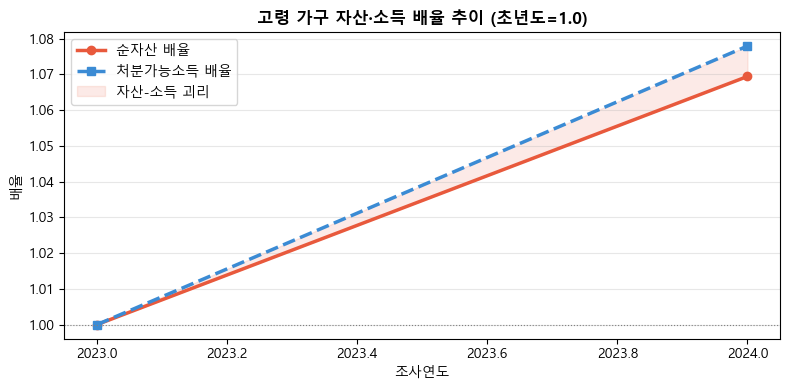

저장: 01_asset_income_gap.png


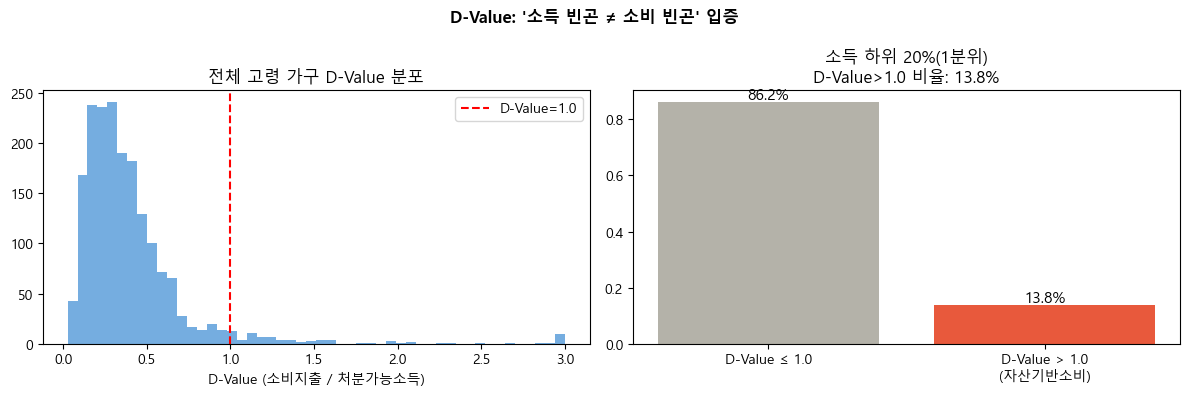

저장: 02_d_value_distribution.png


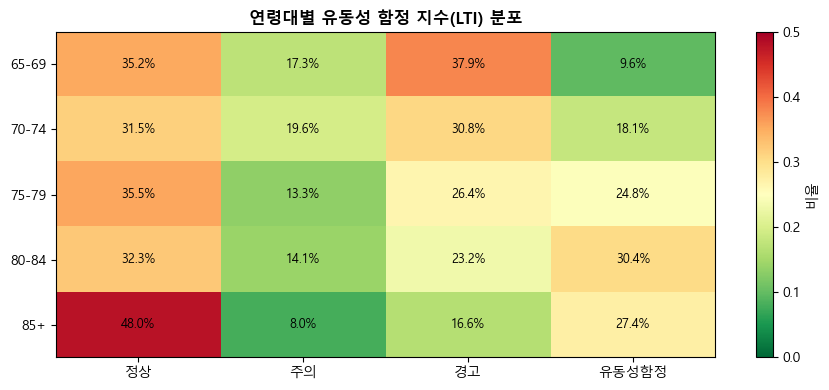

저장: 03_lti_heatmap.png

편향성 점검

① 연령 그룹 분포:
  전기고령자(65-74): 56.2%
  후기고령자(75+): 43.8%

② 소득분위_내부 분포 (이상: 각 20%):
  ✓ 1분위: 19.1%
  ✓ 2분위: 20.3%
  ✓ 3분위: 19.2%
  ✓ 4분위: 20.0%
  ✓ 5분위: 21.4%

③ 부동산 보유율: 62.1% (⚠ 보고서 기준(71.5%) 괴리 확인 필요)

④ 유동성 함정 비율: 19.4%  (10~30% 범위가 유의미)

데이터 활용 명세서 — 2026 국가데이터 활용대회
수도권 고령 가구: 3,646행 (2023+2024, 65세 이상, G1)

[SDC 제공] 가계금융복지조사 / SGIS 소지역통계
[민간 자료] 카드소비(서울) / NICE 대출연체·소득 / 아파트단지소비 / 농협카드 / 외식업물가
[파생변수] D-Value / LTI / AAI
[VDR 규정] K-Anonymity(k=5) / groupby 집계만 반출 / .xlsx·.png 포맷

저장: output\data_manifest.txt


In [10]:
# ================================================================
# [셀 7-b] week5_6 EDA 시각화 3종 + 편향성 점검 + 데이터 명세서
# ================================================================
FIG_DIR = BASE_DIR / 'output' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── 그림 1: 자산-소득 배율 추이 ─────────────────────────────────
try:
    yearly = panel.groupby('조사연도').agg(
        고령순자산평균 = ('순자산', 'mean'),
        고령소득평균   = (INC_COL, 'mean'),
    ).reset_index()
    base_yr = yearly['조사연도'].min()
    base_a  = yearly.loc[yearly['조사연도'] == base_yr, '고령순자산평균'].values[0]
    base_i  = yearly.loc[yearly['조사연도'] == base_yr, '고령소득평균'].values[0]
    yearly['자산_배율'] = yearly['고령순자산평균'] / (base_a + 1e-6)
    yearly['소득_배율'] = yearly['고령소득평균']  / (base_i + 1e-6)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(yearly['조사연도'], yearly['자산_배율'], 'o-', color='#E8593C', lw=2.5, label='순자산 배율')
    ax.plot(yearly['조사연도'], yearly['소득_배율'], 's--', color='#3B8BD4', lw=2.5, label='처분가능소득 배율')
    ax.axhline(1.0, color='gray', lw=0.8, ls=':')
    ax.fill_between(yearly['조사연도'], yearly['자산_배율'], yearly['소득_배율'],
                    alpha=0.12, color='#E8593C', label='자산-소득 괴리')
    ax.set_title('고령 가구 자산·소득 배율 추이 (초년도=1.0)', fontsize=12, fontweight='bold')
    ax.set_xlabel('조사연도'); ax.set_ylabel('배율'); ax.legend(); ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / '01_asset_income_gap.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)
    print('저장: 01_asset_income_gap.png')
except Exception as e:
    print(f'[주의] 그림 1 실패: {e}')

# ── 그림 2: D-Value 분포 ─────────────────────────────────────────
try:
    if 'D_Value' in panel.columns:
        latest  = panel[panel['조사연도'] == panel['조사연도'].max()].copy()
        inc_q   = '소득분위_내부' if '소득분위_내부' in latest.columns else '소득_분위'
        low_inc = latest[latest[inc_q] == (1 if inc_q == '소득분위_내부' else '1분위(하위20%)')]
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].hist(latest['D_Value'].dropna().clip(0, 3), bins=50, color='#3B8BD4', alpha=0.7)
        axes[0].axvline(1.0, color='red', lw=1.5, ls='--', label='D-Value=1.0')
        axes[0].set_title('전체 고령 가구 D-Value 분포')
        axes[0].set_xlabel('D-Value (소비지출 / 처분가능소득)'); axes[0].legend()
        if len(low_inc) > 0:
            over_1 = (low_inc['D_Value'] > 1.0).mean()
            axes[1].bar(['D-Value ≤ 1.0', 'D-Value > 1.0\n(자산기반소비)'],
                        [1-over_1, over_1], color=['#B4B2A9','#E8593C'])
            axes[1].set_title(f'소득 하위 20%(1분위)\nD-Value>1.0 비율: {over_1:.1%}')
            for i, v in enumerate([1-over_1, over_1]):
                axes[1].text(i, v+0.01, f'{v:.1%}', ha='center', fontsize=11)
        fig.suptitle("D-Value: '소득 빈곤 ≠ 소비 빈곤' 입증", fontsize=12, fontweight='bold')
        fig.tight_layout()
        fig.savefig(FIG_DIR / '02_d_value_distribution.png', dpi=150, bbox_inches='tight')
        plt.show(); plt.close(fig)
        print('저장: 02_d_value_distribution.png')
    else:
        print('[주의] D_Value 없음 — 셀 4-c를 먼저 실행하세요')
except Exception as e:
    print(f'[주의] 그림 2 실패: {e}')

# ── 그림 3: LTI 히트맵 ──────────────────────────────────────────
try:
    if 'LTI_등급' in panel.columns:
        latest  = panel[panel['조사연도'] == panel['조사연도'].max()].copy()
        age_col = '가구주_만연령' if '가구주_만연령' in latest.columns else '가구주_연령'
        latest['연령대'] = pd.cut(latest[age_col],
                                  bins=[64,69,74,79,84,150],
                                  labels=['65-69','70-74','75-79','80-84','85+'])
        pivot = pd.crosstab(latest['연령대'], latest['LTI_등급'], normalize='index')
        fig, ax = plt.subplots(figsize=(9, 4))
        im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.5)
        ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                ax.text(j, i, f'{pivot.values[i,j]:.1%}', ha='center', va='center', fontsize=9)
        plt.colorbar(im, ax=ax, label='비율')
        ax.set_title('연령대별 유동성 함정 지수(LTI) 분포', fontsize=12, fontweight='bold')
        fig.tight_layout()
        fig.savefig(FIG_DIR / '03_lti_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show(); plt.close(fig)
        print('저장: 03_lti_heatmap.png')
    else:
        print('[주의] LTI_등급 없음 — 셀 4-c를 먼저 실행하세요')
except Exception as e:
    print(f'[주의] 그림 3 실패: {e}')

# ── 편향성 점검 ──────────────────────────────────────────────────
print('\n' + '='*50)
print('편향성 점검')
print('='*50)
latest = panel[panel['조사연도'] == panel['조사연도'].max()]
print('\n① 연령 그룹 분포:')
for k, v in latest['연령그룹'].value_counts(normalize=True).items():
    print(f'  {k}: {v:.1%}')
inc_q = '소득분위_내부' if '소득분위_내부' in latest.columns else '소득_분위'
print(f'\n② {inc_q} 분포 (이상: 각 20%):')
for k, v in latest[inc_q].value_counts(normalize=True).sort_index().items():
    flag = '✓' if abs(v-0.20) < 0.05 else '⚠'
    print(f'  {flag} {k}분위: {v:.1%}')
re_col = RE_COL if RE_COL in latest.columns else '부동산자산'
if re_col in latest.columns:
    re_rate = (latest[re_col] > 0).mean()
    flag = '✓' if 0.68 <= re_rate <= 0.80 else '⚠ 보고서 기준(71.5%) 괴리 확인 필요'
    print(f'\n③ 부동산 보유율: {re_rate:.1%} ({flag})')
if 'LTI_등급' in latest.columns:
    lti_s = (latest['LTI_등급'] == '유동성함정').mean()
    print(f'\n④ 유동성 함정 비율: {lti_s:.1%}  (10~30% 범위가 유의미)')

# ── 데이터 명세서 ────────────────────────────────────────────────
manifest = f"""
========================================================
데이터 활용 명세서 — 2026 국가데이터 활용대회
========================================================
수도권 고령 가구: {len(panel):,}행 (2023+2024, 65세 이상, G1)

[SDC 제공] 가계금융복지조사 / SGIS 소지역통계
[민간 자료] 카드소비(서울) / NICE 대출연체·소득 / 아파트단지소비 / 농협카드 / 외식업물가
[파생변수] D-Value / LTI / AAI
[VDR 규정] K-Anonymity(k=5) / groupby 집계만 반출 / .xlsx·.png 포맷
========================================================
"""
print(manifest)
manifest_path = BASE_DIR / 'output' / 'data_manifest.txt'
with open(manifest_path, 'w', encoding='utf-8') as f:
    f.write(manifest)
print(f'저장: {manifest_path}')

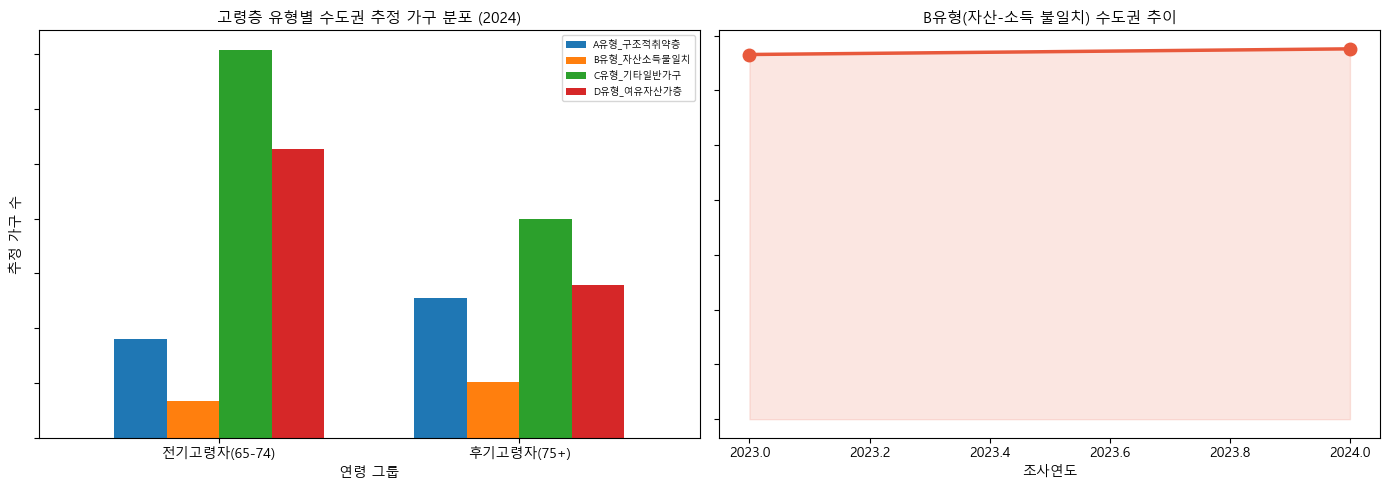

✓ 저장: output\images\01_종합시각화.png


In [11]:
# [셀 7] STEP 10 — 시각화 (노트북 인라인 표시 + 파일 저장)
# 주피터에서는 plt.show()로 노트북 안에 바로 표시됩니다

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 그래프 1: 유형별 분포 (수치 라벨 없음 — VDR 규정 3)
pivot = grp1[grp1['조사연도'] == 2024].pivot_table(
    index='연령그룹', columns='고령층유형',
    values='추정가구수_가중치', aggfunc='sum', fill_value=0
)
pivot.plot(kind='bar', ax=axes[0], width=0.7)
axes[0].set_title('고령층 유형별 수도권 추정 가구 분포 (2024)', fontsize=11)
axes[0].set_xlabel('연령 그룹')
axes[0].set_ylabel('추정 가구 수')
axes[0].set_yticklabels([])   # 수치 미표기 (VDR 규정 3)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=7)

# 그래프 2: B유형 연도별 추이 (수치 라벨 없음)
trend = grp1[grp1['고령층유형'] == 'B유형_자산소득불일치'].groupby(
    '조사연도')['추정가구수_가중치'].sum()
axes[1].plot(trend.index, trend.values, 'o-', color='#E8593C', lw=2.5, ms=9)
axes[1].fill_between(trend.index, trend.values, alpha=0.15, color='#E8593C')
axes[1].set_title('B유형(자산-소득 불일치) 수도권 추이', fontsize=11)
axes[1].set_xlabel('조사연도')
axes[1].set_yticklabels([])   # 수치 미표기 (VDR 규정 3)

plt.tight_layout()
# 노트북 화면 표시
plt.show()
# 파일 저장 (VDR 반출용)
fig.savefig(OUT_IMG / '01_종합시각화.png', dpi=150, bbox_inches='tight')
print(f'✓ 저장: {OUT_IMG / "01_종합시각화.png"}')

In [12]:
# [셀 8] 최종 산출물 확인
from pathlib import Path

xlsx_files = list(OUT_XLS.glob('*.xlsx'))
png_vdr    = list(OUT_IMG.glob('*.png'))                         # VDR 이미지 (output/images)
fig_dir    = BASE_DIR / 'output' / 'figures'
png_eda    = list(fig_dir.glob('*.png')) if fig_dir.exists() else []  # EDA 이미지 (output/figures)
all_png    = png_vdr + png_eda
csv_files  = list((BASE_DIR / 'output').glob('*.csv')) if (BASE_DIR / 'output').exists() else []

print('=' * 55)
print('  파이프라인 완료')
print('=' * 55)

print(f'\n엑셀 산출물 ({len(xlsx_files)}개):')
for f in sorted(xlsx_files):
    try:
        df_tmp = pd.read_excel(f)
        print(f'  {f.name}  ({len(df_tmp)}행 x {len(df_tmp.columns)}열)')
    except Exception:
        print(f'  {f.name}  (읽기 실패)')

print(f'\nVDR 이미지 ({len(png_vdr)}개, output/images/):')
for f in sorted(png_vdr):
    print(f'  {f.name}')

print(f'\nEDA 이미지 ({len(png_eda)}개, output/figures/):')
for f in sorted(png_eda):
    print(f'  {f.name}')

print(f'\nCSV 산출물 ({len(csv_files)}개, output/):')
for f in sorted(csv_files):
    print(f'  {f.name}')

if not all_png:
    print('\n[주의] 이미지 없음 — 셀 7(VDR 시각화)과 셀 7-b(EDA)를 먼저 실행하세요')

print(f'\n출력 위치: {OUT_XLS.resolve()}')

  파이프라인 완료

엑셀 산출물 (14개):
  01_유형별_집계.xlsx  (16행 x 10열)
  02_수도권별_유형집계.xlsx  (16행 x 8열)
  03_주택종류별_집계.xlsx  (16행 x 8열)
  04_SGIS_시군구별_주거현황.xlsx  (36행 x 8열)
  04_다각도_그루핑_매트릭스.xlsx  (95행 x 15열)
  05_SGIS_시군구별_주거현황.xlsx  (36행 x 7열)
  05_카드소비서울_시군구업종별.xlsx  (487행 x 6열)
  06_NICE_대출연체_시군구별.xlsx  (57행 x 13열)
  06_카드소비서울_시군구업종별.xlsx  (487행 x 6열)
  07_NICE_대출연체_시군구별.xlsx  (57행 x 10열)
  07_NICE_소득_시군구별.xlsx  (50행 x 7열)
  08_아파트단지소비_시군구별.xlsx  (0행 x 13열)
  09_농협카드_아파트단지소비_시군구별.xlsx  (0행 x 4열)
  10_외식업물가_시군구별.xlsx  (0행 x 19열)

VDR 이미지 (1개, output/images/):
  01_종합시각화.png

EDA 이미지 (3개, output/figures/):
  01_asset_income_gap.png
  02_d_value_distribution.png
  03_lti_heatmap.png

CSV 산출물 (2개, output/):
  for_teamB_model_input.csv
  for_teamC_sgis_grid.csv

출력 위치: C:\Users\yooyj\OneDrive\문서\Code\Data\output\excel



04. 04_SGIS_시군구별_주거현황.xlsx
분석 목적
수도권 시군구별 65세 이상 고령 가구의 주거 특성을 파악하여 자산재생 핫스팟을 도출한다.
상세 설명
가구통계등록부와 주택통계등록부를 거처일련번호로 결합 후 수도권 필터링, 65세 이상 추출, 시군구×연령그룹×거처종류 단위 집계한다.
분석 DB

가구통계등록부 (HOUSEHOLD_2023.txt)
주택통계등록부 (HOUSING_2023.txt)

기존 변수
행정구역분류코드, 만나이, 거처종류코드, 가구원수, 건축승인연도, 주거용면적, 거처일련번호
생성 변수
시군구코드, 연령그룹, 건물연령, 노후건물비율
산출 결과
시군구×연령그룹×거처종류별 고령가구수, 평균가구원수, 평균주거면적, 평균노후건물비율 제공 (5가구 미만 행 삭제).
노후건물비율 높고 고령가구 밀집 시군구 = 주택연금·다운사이징 우선 정책 대상 지역 식별 가능.

05. 05_카드소비서울_시군구업종별.xlsx
분석 목적
수도권 거주 65세 이상 노인이 서울 가맹점에서 업종별로 소비하는 금액을 자치구 단위로 파악한다.
상세 설명
내국인국내카드소비_서울(통합카드) 2024년 1~12월에서 수도권 거주·65세 이상·개인·노인가구 조건으로 필터링 후 자치구×업종×연령코드 단위 연간 집계한다.
분석 DB

내국인국내카드소비_서울(통합카드) (CARD_DOMESTIC_SEOUL_202401.txt ~ CARD_DOMESTIC_SEOUL_202412.txt, 총 12개 파일)

기존 변수
통합카드5세단위연령코드, 조직구분코드, 통합카드가구형태코드, 고객행정구역분류시도코드, 가맹점행정구역분류시군구코드, 통합카드업종3레벨코드, 카드사용건수, 카드사용금액, 1인당평균사용금액
생성 변수
카드사용건수합, 카드사용금액합, 연간_카드사용건수, 연간_카드사용금액, 평균1인당사용금액
산출 결과
자치구×업종×연령코드별 연간 카드 사용건수·금액·1인당 평균금액 제공 (5건 미만 행 삭제).
서울 의료업종(L코드) 소비 집중 자치구 및 수도권 고령자 서울 상권 소비 패턴 파악 가능.

06. 06_NICE_대출연체_시군구별.xlsx
분석 목적
수도권 65세 이상 고령층의 시군구별 대출 규모 및 연체 현황을 파악하여 유동성 위기 지역을 식별한다.
상세 설명
신용정보_대출및연체(NICE) 2024년 1~12월을 시군구 단위·연령구간 65·70·직업구분 전체·수도권 조건으로 필터링 후 연간 집계한다.
분석 DB

신용정보_대출및연체(NICE) (NICE_LOAN_AGE_202401.txt ~ NICE_LOAN_AGE_202412.txt, 총 12개 파일)

기존 변수
연령구간대, 광역시도코드, 시군구코드, 성별, 대출잔액_평균금액, 대출잔액_주택담보_평균금액, 총대출잔액, 대출평균이자율, 월_연체보유자수_합계, 평균연체금액, 연체금액
생성 변수
연체비율 (연체금액합 ÷ 총대출잔액)
산출 결과
시군구×연령구간×성별별 평균대출잔액·주담대잔액·이자율·연체보유자수·연체비율 제공 (5명 미만 행 삭제).
연체비율 상위 시군구와 LTI(유동성함정지수) 높은 지역 교차 검증 가능.

07. 07_NICE_소득_시군구별.xlsx
분석 목적
수도권 65세 이상 고령층의 시군구별 추정 연소득을 파악하여 카드소비와의 괴리를 검증한다.
상세 설명
신용정보_소득(NICE) 2024년 1~12월을 시군구 단위·연령구간 65·70·직업구분 전체·수도권 조건으로 필터링 후 연간 집계한다.
분석 DB

신용정보_소득(NICE) (NICE_INCOM_AGE_202401.txt ~ NICE_INCOM_AGE_202412.txt, 총 12개 파일)

기존 변수
연령구간대, 광역시도코드, 시군구코드, 성별, 평균_연소득_금액, 중위_연소득_금액, 거주자수, 총연소득합계
생성 변수
거주자수합, 평균_연소득_금액, 중위_연소득_금액, 총연소득합계 (12개월 집계)
산출 결과
시군구×연령구간×성별별 추정 평균·중위 연소득, 거주자수 제공 (5명 미만 행 삭제).
가계금융복지조사 처분가능소득 대비 추정 소득 괴리 확인 가능.

08. 08_아파트단지소비_시군구별.xlsx
분석 목적
수도권 아파트 거주 60대 이상 노인의 시군구별 추정 소득 및 소비 관심사 분포를 파악한다.
상세 설명
아파트단지별소비(통합카드) 2024년 1~12월에서 수도권 거주·60대 이상 조건으로 필터링 후 시군구×성별 연간 집계한다.
분석 DB

아파트단지별소비(통합카드) (CARD_APARTMENT_202401.txt ~ CARD_APARTMENT_202412.txt, 총 12개 파일)

기존 변수
통합카드10세단위연령코드, 고객행정구역분류시도코드, 고객행정구역분류시군구코드, 통합카드성별코드, 통합카드아파트단지코드, 연평균소득금액, 건강관심비율, 골프관심비율, 독서관심비율, 뷰티관심비율, 쇼핑관심비율, 여행관심비율, 온라인쇼핑관심비율, 식도락관심비율
생성 변수
집계단지수, 평균_연평균소득, 평균_건강관심비율, 평균_골프관심비율, 평균_여행관심비율, 평균_식도락관심비율 등
산출 결과
시군구×성별별 추정 평균소득, 소비 관심사 평균 비율 제공 (단지수 5 미만 행 삭제).
건강·의료 관심이 집중된 시군구를 고령 취약 지역 보완 지표로 활용 가능.

09. 09_농협카드_아파트단지소비_시군구별.xlsx
분석 목적
농협카드 기준 수도권 60대 이상 아파트 거주자의 추정 소득을 파악하여 경기·인천 외곽 지역 데이터를 보완한다.
상세 설명
아파트단지별소비(농협카드) 2024년 1~12월에서 수도권 거주·60대 이상 조건으로 필터링 후 시군구×성별 연간 집계한다.
분석 DB

아파트단지별소비(농협카드) (NHCRD_APARTMENT_202401.txt ~ NHCRD_APARTMENT_202412.txt, 총 12개 파일)

기존 변수
통합카드10세단위연령코드, 고객행정구역분류시도코드, 고객행정구역분류시군구코드, 통합카드성별코드, 통합카드아파트단지코드, 연평균소득금액
생성 변수
집계단지수, 평균_연평균소득
산출 결과
시군구×성별별 집계단지수, 추정 평균 연소득 제공 (5 미만 행 삭제).
통합카드(08파일) 대비 경기·인천 외곽 지역 보완 자료로 활용.

10. 10_외식업물가_시군구별.xlsx
분석 목적
수도권 시군구별 외식 평균 단가와 전년 대비 물가 변화율을 산출하여 고령층 생활비 부담 지역을 식별한다.
상세 설명
외식업물가_시군구(NICE) 2025년 1월 기준 단일 파일에서 수도권 광역시도코드(11·28·41)로 필터링 후 시군구×업종별 집계한다.
분석 DB

외식업물가_시군구(NICE) (TN_PD_NICE_POG_SGG_202501.txt, 단일 파일)

기존 변수
광역시도코드, 시군구코드, 시군구명, 업종코드, 업종명, 평균단가, 거래건수, 평균매출금액, 전월대비변화율, 전년동월대비변화율
생성 변수
평균단가_mean, 거래건수_sum, 평균매출금액_mean, 전월대비변화율_mean, 전년동월대비변화율_mean, 집계건수
산출 결과
시군구×업종별 평균 단가, 전년 대비 물가 변화율 제공 (집계건수 5 미만 행 삭제).
외식 물가 상승 시군구 = 고정 소득 고령층 생활비 압박 지역 식별 가능.